# Lab 2: Data Analysis and Visualization
## i242548_DSB


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")

df = pd.read_csv("adult.csv")
df.replace("?", np.nan, inplace=True)
print("Before dropping missing:", df.shape)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("After dropping missing:", df.shape)
df.head()

Before dropping missing: (32561, 15)
After dropping missing: (30162, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
1,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
2,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
3,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
4,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


## Task 1:

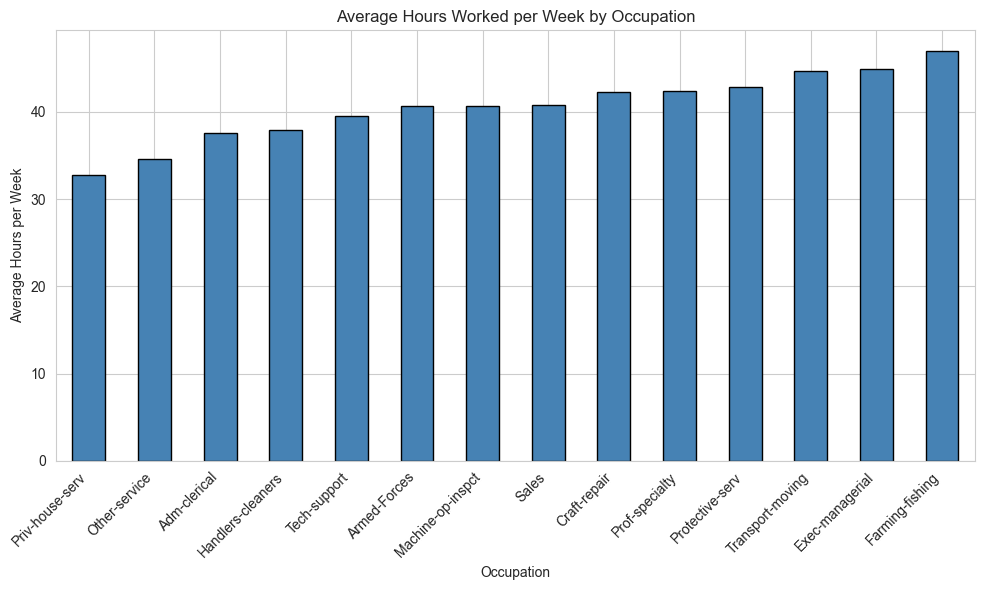

In [9]:
avg_hours_by_occ = df.groupby("occupation")["hours.per.week"].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
avg_hours_by_occ.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Average Hours Worked per Week by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Task 2: 

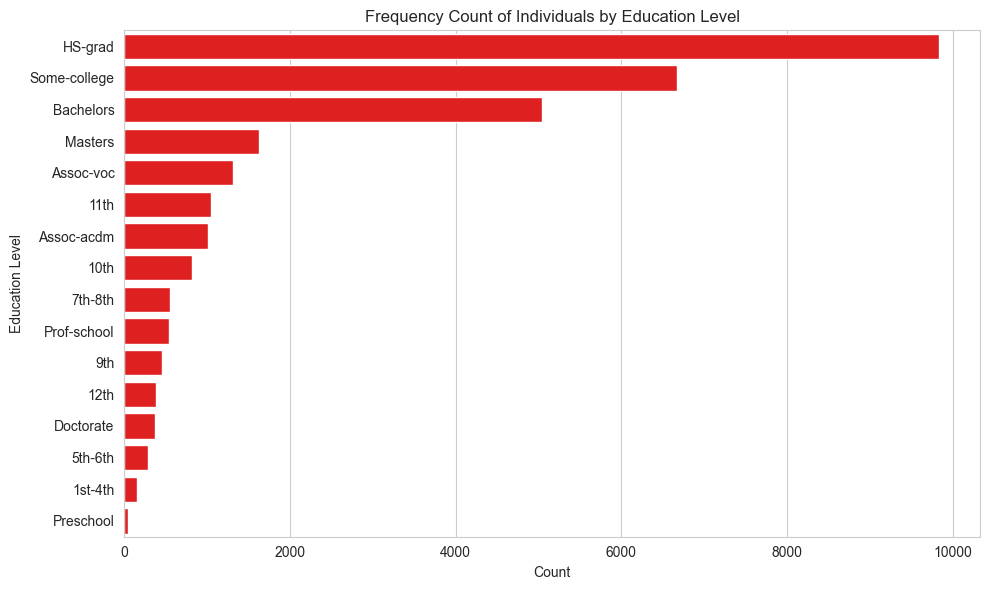

In [32]:
# TASK 2
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='education', color="red", order=df['education'].value_counts().index)
plt.title('Frequency Count of Individuals by Education Level')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.tight_layout()
plt.show()

## Task 3: 

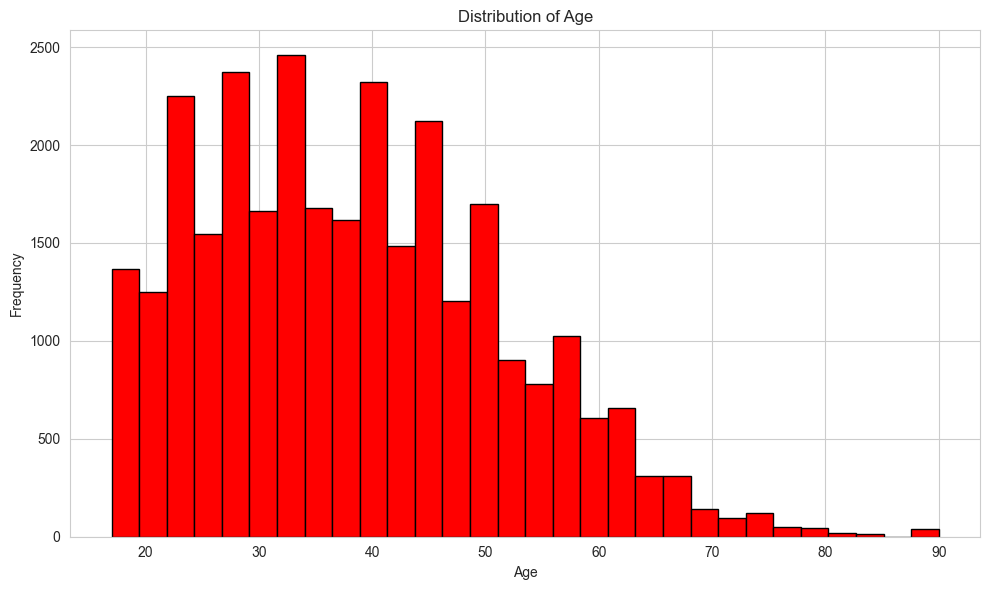

The distribution of age is skewed right (positively skewed with a skewness coefficient of ~0.56),


In [34]:
plt.figure(figsize=(10, 6))
plt.hist(df["age"], bins=30, color="red", edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("The distribution of age is skewed right (positively skewed with a skewness coefficient of ~0.56),")

## Task 4: 

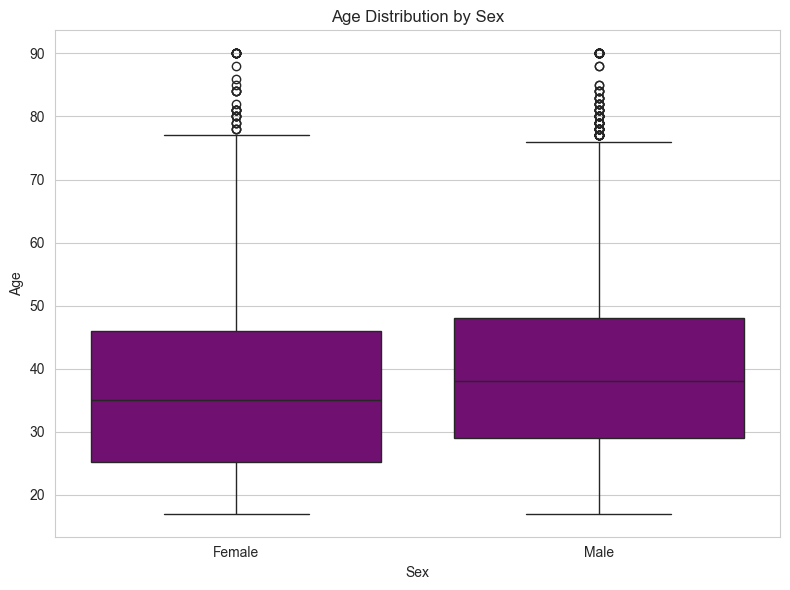

In [51]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="sex", y="age", color="purple")
plt.title("Age Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

## Task 5: 

In [52]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[(df['age'] < lower) | (df['age'] > upper)]

print(f"Number of IQR outliers: {len(outliers_iqr)}")

Number of IQR outliers: 169


## Task 6:

In [7]:
df['zscore'] = stats.zscore(df['age'])
outliers_z = df[df['zscore'].abs() > 3]

print(f"Number of z-score outliers: {len(outliers_z)}")
print(f"Number of IQR outliers:     {len(outliers_iqr)}")

Number of z-score outliers: 120
Number of IQR outliers:     169


**Comparison:** IQR and z-score do *not* flag the same number of outliers. This traces back to Task 3 — `age` is right-skewed (skew = 0.53), not symmetric. IQR only relies on quartiles, so it doesn't care about the shape of the tails and flags any value past the fence regardless of skew. Z-score, on the other hand, assumes the data is roughly bell-shaped and symmetric around the mean; on a skewed column, the right tail pulls the mean and standard deviation upward, which can make z-score more conservative (flag fewer points) on the very high end than a purely quartile-based method would. In short: IQR is the more trustworthy method here since it doesn't assume symmetry.

## Task 7:

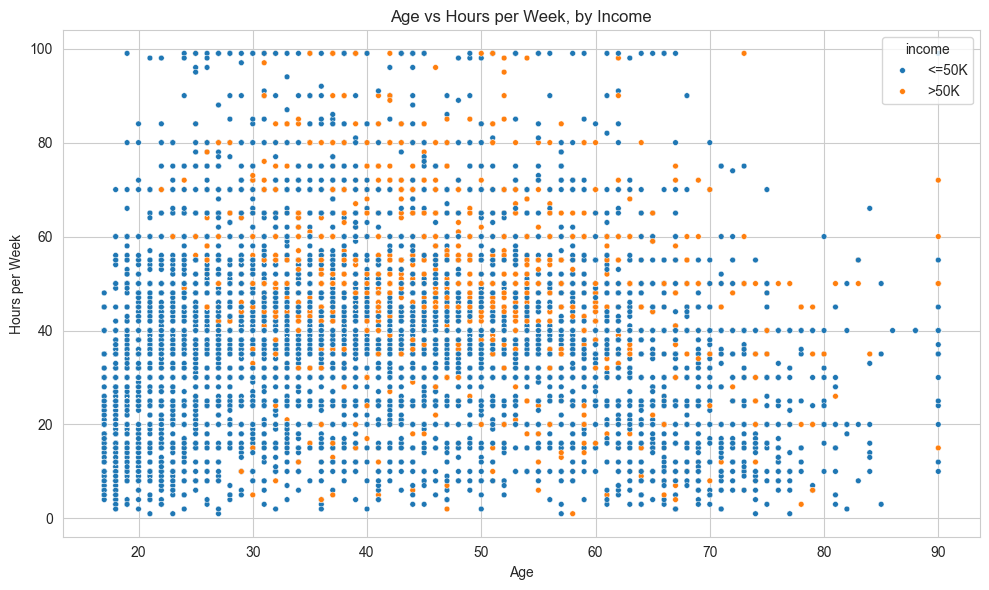

Correlation (age vs hours.per.week): 0.102


In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="hours.per.week", hue="income", alpha=1, s=17)
plt.title("Age vs Hours per Week, by Income")
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.tight_layout()
plt.show()

print("Correlation (age vs hours.per.week):", df['age'].corr(df['hours.per.week']).round(3))

## Task 8: Line/Area Chart — Trend Across an Ordered Variable

**Why `education.num`:** the manual specifically calls this out as the ordered variable to use for the Adult dataset, since there's no real time column. `education.num` is a numeric encoding of education level (1 = Preschool ... 16 = Doctorate), so it has a genuine natural order — unlike, say, `occupation`, which has no inherent ranking and shouldn't be connected with a line (that's the "no disconnected bars" caution from the manual, applied in reverse: don't draw a line through unordered categories).

We'll plot average `hours.per.week` across `education.num`, once as a line and once as a filled area, to compare the visual impression.

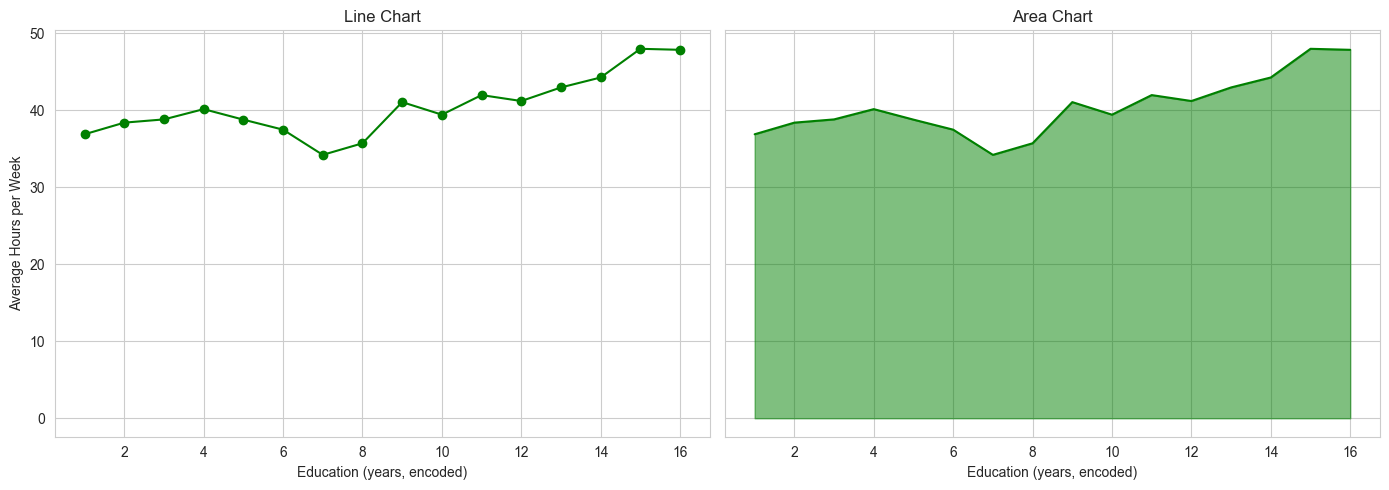

In [49]:
avg_hours_by_edu = df.groupby("education.num")["hours.per.week"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, marker="o", color="green")
axes[0].set_title("Line Chart")
axes[0].set_xlabel("Education (years, encoded)")
axes[0].set_ylabel("Average Hours per Week")

axes[1].fill_between(avg_hours_by_edu.index, avg_hours_by_edu.values, color="green", alpha=0.5)
axes[1].plot(avg_hours_by_edu.index, avg_hours_by_edu.values, color="green")
axes[1].set_title("Area Chart")
axes[1].set_xlabel("Education (years, encoded)")

plt.tight_layout()
plt.savefig("task8_line_area.png", dpi=100)
plt.show()

**Comparing the two:** both charts show the exact same trend — average hours worked rises fairly steadily as education level increases. The line chart shows just the direction of change cleanly. The area chart's fill draws your eye to the *magnitude/volume* under the curve, which makes the overall climb look more dramatic even though the underlying numbers are identical. For this data, since we care about the trend direction more than a cumulative "volume," the line chart is the more honest choice — the area chart risks visually overstating how much hours grow with education.

## Task 9: 

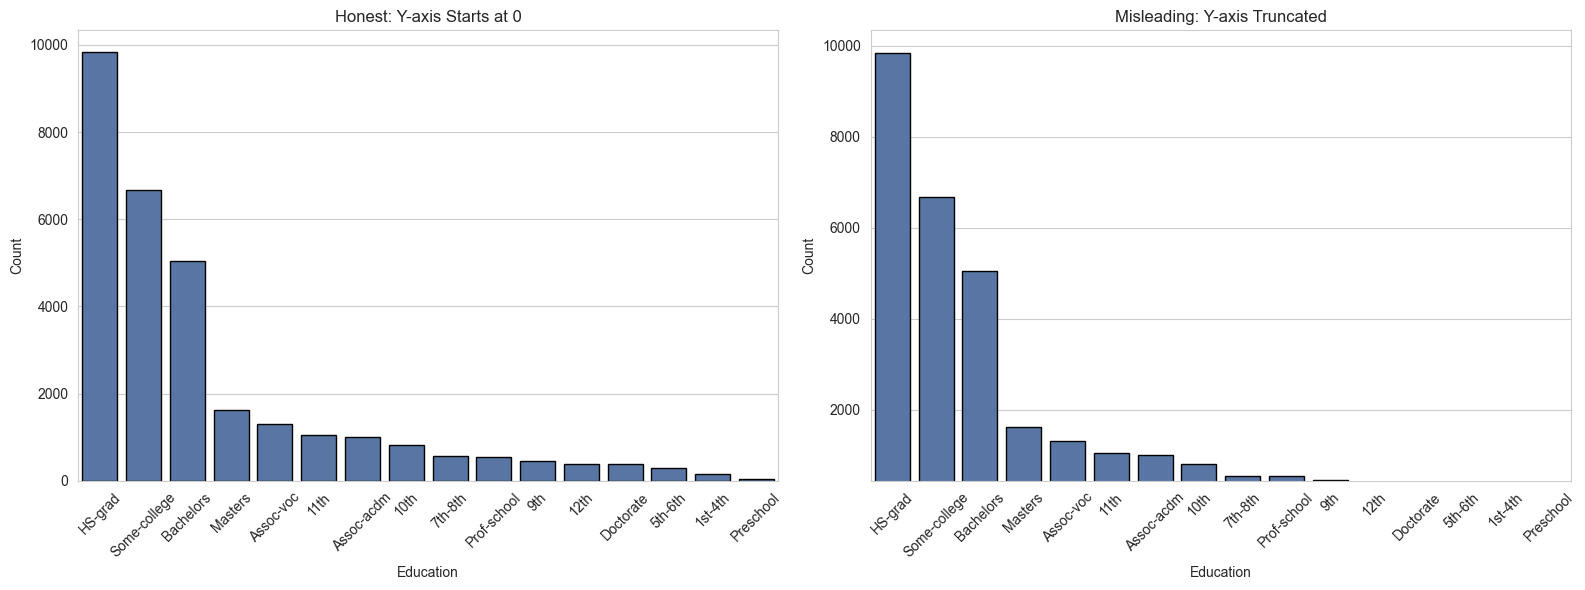

In [53]:
order = df["education"].value_counts().index
counts = df["education"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x="education", order=order, color="#4C72B0", edgecolor="black", ax=axes[0])
axes[0].set_title("Honest: Y-axis Starts at 0")
axes[0].set_xlabel("Education")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x="education", order=order, color="#4C72B0", edgecolor="black", ax=axes[1])
axes[1].set_title("Misleading: Y-axis Truncated")
axes[1].set_xlabel("Education")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(bottom=counts.min() + 400)

plt.tight_layout()
plt.show()

**Write-up (2-3 sentences):** Even though both charts plot the exact same counts, truncating the y-axis in the second version exaggerates the differences between education levels — bars that were only modestly different in the honest version (like 11th vs 10th vs Prof-school) now look wildly different in height, because the visible range no longer reflects the true zero-based proportions. This is a classic graphical integrity violation: a reader skimming the truncated chart would walk away thinking rare education levels are drastically rarer than common ones, when the real gap, while real, is far less extreme than the chart implies.